# Streaming Segmentation — Making Algorithm 2 Run Live

Everything before this notebook is offline analysis. This is the first piece of the **demo
app**: getting SOFI Algorithm 2 to run on a live camera without changing what it does.

Two things have to be true before a webcam demo is worth building, and neither was obvious:

1. **Algorithm 2 is non-causal.** It smooths with a *centred* rolling mean, declares a minimum
   only by looking ±`run` frames around a candidate, and merges nearby minima keeping the
   deepest — which means a hold cannot be confirmed until `min_sep` further frames have
   arrived. A naive live port silently becomes a different algorithm.
2. **Its parameters are frame counts tuned at 50 fps.** A webcam is usually 30 fps. The same
   frame counts then mean different *durations*, and the method is tuned to the physical
   rhythm of fingerspelling, not to a frame index.

Both are measured here against the 218 validation clips.

## Setup

In [1]:
import json
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from canonicalize_words import spelling_for_labels
from sofi_dynamic import segment_clip, KP_COLS_X, KP_COLS_Y
from sofi_streaming import StreamingSegmenter, TUNED_FPS

pd.set_option("display.width", 220)
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("hand_keypoints_features.csv")
mapping = json.load(open("word_letter_mapping.json", encoding="utf-8"))
df["spelling"] = df["video_id"].map({v: spelling_for_labels(v) for v in df["video_id"].unique()})

clips = []
for (sg, vid), sub in df.groupby(["signer_id", "video_id"], sort=True):
    sub = sub.sort_values("frame_id").reset_index(drop=True)
    sp = sub["spelling"].iloc[0]
    if sp not in mapping or sub["hand_detected"].mean() < 0.5 or len(sub) < 30:
        continue
    clips.append({"signer": sg, "video_id": vid, "spelling": sp,
                  "n_letters": len(mapping[sp]), "sub": sub})
true_counts = np.array([c["n_letters"] for c in clips])
print(f"{len(clips)} validation clips")

218 validation clips


## The latency budget

The delay is not an implementation choice — it is the amount of future the algorithm needs
before it can commit to a decision.

In [2]:
s = StreamingSegmenter(fps=TUNED_FPS)
print(f"smoothing needs   {(s.smooth_win-1)//2:>3} frames ahead  (centred {s.smooth_win}-frame mean)")
print(f"minimum test needs{s.run:>4} frames ahead  (+/-run window)")
print(f"collapse needs    {s.min_sep:>3} frames ahead  (a deeper minimum may still arrive)")
print(f"-> delay = {s.delay} frames = {s.latency_ms:.0f} ms at {TUNED_FPS:.0f} fps")

smoothing needs     6 frames ahead  (centred 13-frame mean)
minimum test needs   7 frames ahead  (+/-run window)
collapse needs     15 frames ahead  (a deeper minimum may still arrive)
-> delay = 15 frames = 300 ms at 50 fps


300 ms. Comfortably inside tolerance for fingerspelling — the hand is still mid-transition to
the next letter when the previous one is reported.

## Does the streaming version agree with the offline one?

Replay every clip through `StreamingSegmenter` one frame at a time and compare the emitted hold
frames against `sofi_dynamic.segment_clip`. These should be nearly identical; where they differ
it is almost entirely the handling of frames MediaPipe missed (offline interpolates across the
gap, a live stream cannot see the future and carries the last pose forward).

In [3]:
def run_stream(sub, fps, **kw):
    X = sub[KP_COLS_X].to_numpy(float)
    Y = sub[KP_COLS_Y].to_numpy(float)
    det = sub["hand_detected"].to_numpy()
    seg = StreamingSegmenter(fps=fps, **kw)
    out = []
    for i in range(len(sub)):
        events = seg.push(None, None) if det[i] == 0 else seg.push(X[i], Y[i])
        out += [h.frame for h in events]
    out += [h.frame for h in seg.finish()]
    return out, seg

offline = [list(map(int, segment_clip(c["sub"])["minima"])) for c in clips]
online = [run_stream(c["sub"], TUNED_FPS)[0] for c in clips]

identical = sum(a == b for a, b in zip(offline, online))
cnt_diff = np.array([len(b) - len(a) for a, b in zip(offline, online)])
pos = np.array([abs(x - y) for a, b in zip(offline, online) if len(a) == len(b)
                for x, y in zip(a, b)])

print(f"identical hold lists : {identical}/{len(clips)}  ({100*identical/len(clips):.1f}%)")
print(f"count difference     : mean {cnt_diff.mean():+.2f}, MAE {np.abs(cnt_diff).mean():.2f}, "
      f"max |diff| {np.abs(cnt_diff).max()}")
print(f"frame offset         : {100*(pos==0).mean():.1f}% land on the exact same frame, "
      f"mean {pos.mean():.2f}, max {pos.max()}  (n={len(pos)})")

identical hold lists : 190/218  (87.2%)
count difference     : mean +0.00, MAE 0.05, max |diff| 2
frame offset         : 97.3% land on the exact same frame, mean 0.20, max 37  (n=1314)


In [4]:
# and does it still track letter count as well?
def summarize(counts, tag):
    e = np.array(counts) - true_counts
    return {"variant": tag, "MAE": np.abs(e).mean(), "exact %": 100*(e == 0).mean(),
            "within +/-1 %": 100*(np.abs(e) <= 1).mean(),
            "corr": np.corrcoef(counts, true_counts)[0, 1]}

print(pd.DataFrame([summarize([len(a) for a in offline], "offline (batch)"),
                    summarize([len(b) for b in online], "streaming (causal)")])
      .round(3).to_string(index=False))

           variant   MAE  exact %  within +/-1 %  corr
   offline (batch) 1.193   32.110         72.018 0.789
streaming (causal) 1.234   29.817         71.560 0.781


Streaming costs almost nothing: MAE 1.23 against 1.19, and 97 % of matched holds land on the
exact same frame. **The real-time constraint is not what limits this pipeline.**

## Framerate transfer — the part that would have broken the demo

The tuned values (`smooth=13, run=7, min_sep=15`) are frame counts at 50 fps. At 30 fps the
same counts describe a *longer* stretch of real time, and the segmenter looks for holds that
are half again as long as the ones people actually make.

Comparing two ports, with clips resampled to simulate a slower camera:

- **seconds-relative** — convert the tuned durations (0.26 s / 0.14 s / 0.30 s) to frame counts
  at the actual framerate. This is what `sofi_streaming.py` does.
- **naive frame reuse** — keep 13 / 7 / 15 as frame counts, which is what a straight port
  would do.

In [5]:
def resample(sub, src_fps, dst_fps):
    """Simulate a slower camera by dropping frames."""
    n = len(sub)
    idx = np.unique(np.round(np.arange(0, n, src_fps / dst_fps)).astype(int))
    return sub.iloc[idx[idx < n]].reset_index(drop=True)

rows = []
for fps in (50, 30, 25, 15):
    variants = {"seconds-relative": {}}
    if fps != 50:
        variants["naive frame reuse"] = dict(smooth_sec=13/fps, run_sec=7/fps, min_sep_sec=15/fps)
    for tag, kw in variants.items():
        counts = []
        for c in clips:
            sub = resample(c["sub"], 50, fps) if fps != 50 else c["sub"]
            out, seg = run_stream(sub, fps, **kw)
            counts.append(len(out))
        e = np.array(counts) - true_counts
        rows.append({"fps": fps, "mode": tag, "smooth": seg.smooth_win, "run": seg.run,
                     "min_sep": seg.min_sep, "latency ms": round(seg.latency_ms),
                     "MAE": np.abs(e).mean(), "exact %": 100*(e == 0).mean(),
                     "within +/-1 %": 100*(np.abs(e) <= 1).mean()})
fps_tbl = pd.DataFrame(rows)
print(fps_tbl.round(2).to_string(index=False))

 fps              mode  smooth  run  min_sep  latency ms  MAE  exact %  within +/-1 %
  50  seconds-relative      13    7       15         300 1.23    29.82          71.56
  30  seconds-relative       9    4        9         300 1.17    27.98          72.94
  30 naive frame reuse      13    7       15         500 2.61     2.75          23.39
  25  seconds-relative       7    4        8         320 1.18    31.19          71.56
  25 naive frame reuse      13    7       15         600 3.35     0.00           9.17
  15  seconds-relative       5    2        4         267 1.37    26.61          67.43
  15 naive frame reuse      13    7       15        1000 4.56     0.00           0.00


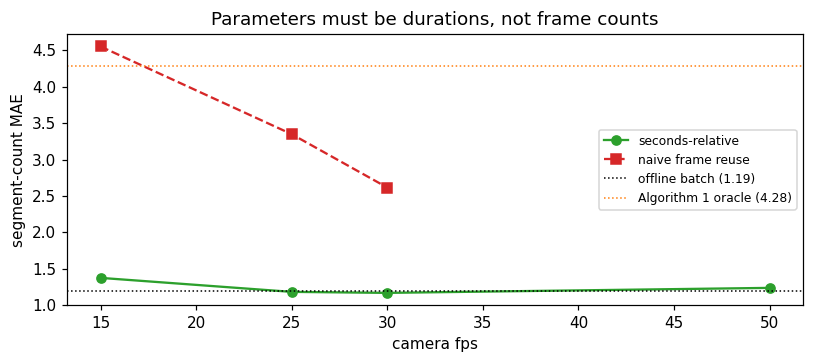

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 3.4))
for tag, style in [("seconds-relative", dict(marker="o", color="C2")),
                   ("naive frame reuse", dict(marker="s", color="C3", ls="--"))]:
    d = fps_tbl[fps_tbl["mode"] == tag].sort_values("fps")
    ax.plot(d.fps, d.MAE, label=tag, **style)
ax.axhline(1.19, color="k", lw=1, ls=":", label="offline batch (1.19)")
ax.axhline(4.28, color="C1", lw=1, ls=":", label="Algorithm 1 oracle (4.28)")
ax.set_xlabel("camera fps"); ax.set_ylabel("segment-count MAE")
ax.set_title("Parameters must be durations, not frame counts")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

A straight port would have been **worse than Algorithm 1** at 15 fps (MAE 4.56 vs 4.28) and
badly degraded at the 30 fps a webcam actually delivers (2.61, with exact-count collapsing from
~30 % to 2.8 %). The seconds-relative version holds at ~1.2 MAE across 50 / 30 / 25 fps and only
softens at 15.

This is the kind of bug that would have looked like "the demo just doesn't work very well" and
been extremely hard to trace back to a unit mismatch.

## Browser parity

The live page runs the segmenter in JavaScript so that no video leaves the client — only hand
keypoints are processed, and only the cropped hold frames would ever be sent anywhere. A port
that quietly diverges from the validated Python would be very hard to notice by eye, so it is
checked rather than assumed.

The cell below exports a fixture of real keypoint sequences plus the frames Python emits for
them, and replays it through `web/sofi_streaming.js` under Node.

In [7]:
import tempfile, os

cases = []
for i, c in enumerate(clips):
    if i % 9:
        continue
    sub = c["sub"]
    X = sub[KP_COLS_X].to_numpy(float); Y = sub[KP_COLS_Y].to_numpy(float)
    det = sub["hand_detected"].to_numpy()
    frames = [None if det[j] == 0 else [list(map(float, X[j])), list(map(float, Y[j]))]
              for j in range(len(sub))]
    for fps in (50, 30):
        out, seg = run_stream(sub, fps)
        cases.append({"signer": c["signer"], "video": c["video_id"], "fps": fps,
                      "frames": frames, "expected": [int(v) for v in out],
                      "config": {"smooth": seg.smooth_win, "run": seg.run,
                                 "min_sep": seg.min_sep, "delay": seg.delay}})

fixture = os.path.join(tempfile.gettempdir(), "sofi_fixture.json")
json.dump(cases, open(fixture, "w"), separators=(",", ":"))
print(f"{len(cases)} cases exported")

r = subprocess.run(["node", "web/test_parity.mjs", fixture],
                   capture_output=True, text=True)
print(r.stdout or r.stderr)
print("PARITY OK" if r.returncode == 0 else "PARITY FAILED")

50 cases exported


fixture cases : 50
frames replayed: 9958
exact match    : 50
mismatch       : 0

PARITY OK


Byte-identical, at both framerates. The browser implementation is the validated one.

## Running the demo

```bash
python -m http.server 8000
# then open http://localhost:8000/web/
```

A plain `file://` open will not work: ES modules and `getUserMedia` both require a real origin
(`localhost` counts as secure, so no HTTPS is needed locally).

The page measures the actual camera framerate before constructing the segmenter, shows the live
OFI trace with confirmed holds marked, and captures the cropped hand at each hold — which is
exactly the input a letter classifier will consume.

### What it does *not* do

Letter recognition is not wired up, because [letter_classifier.ipynb](letter_classifier.ipynb)
showed the keypoint-geometry features do not transfer across signers (6.8 % against a 9.1 %
baseline). The page is deliberately honest about that rather than shipping a recognition box
that would output noise.

### What plugs in next

1. The hold crops are already produced in signing order — a letter CNN takes them directly.
2. The classifier should emit **per-frame posteriors** rather than one label per hold, and a
   CTC decoder should produce the final string. Free segmentation is exact only ~32 % of the
   time and within ±1 letter ~72 %, so any design that hard-commits to segment boundaries
   inherits that error; CTC absorbs insertions and deletions natively.
3. Given the cross-signer result, plan for a **calibration step** — a few known letters from
   the user, few-shot adapted — rather than assuming a signer-independent model.